# Problem Statement

Accurately forecasting short‑term household energy usage is essential for improving energy efficiency, reducing costs, and supporting smart‑grid decision‑making. However, raw household power consumption data is often noisy, irregular, and recorded at minute‑level intervals, making it difficult to analyze directly. To build a reliable forecasting model, the data must be cleaned, resampled, and transformed into a structured time‑series format that captures meaningful temporal patterns.

# Objective

This project aims to address the challenge of predicting hourly household energy usage by analyzing historical consumption patterns and applying time‑series forecasting models. By understanding how energy usage varies across hours, days, and weekends, we can build models that anticipate short‑term demand and provide actionable insights.

# Dataset Description

he dataset used in this project is the Household Power Consumption Dataset, which contains time‑stamped measurements of electrical power usage in a single household. The dataset includes the following columns:

Date – calendar date (dd/mm/yyyy)
Time – time of day (hh:mm:ss)
Global_active_power – total active power consumed (kilowatts)
Global_reactive_power – reactive power consumed (kilowatts)
Voltage – voltage (volts)
Global_intensity – current intensity (amps)
Sub_metering_1 – energy usage in kitchen (watt‑hours)
Sub_metering_2 – energy usage in laundry room (watt‑hours)
Sub_metering_3 – energy usage in climate control (watt‑hours)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

# Loading and EDA

In [24]:
df = pd.read_csv('household_power_consumption.csv')

df.describe()

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [25]:
df.shape

(1048575, 9)

In [26]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Text(0.5, 1.0, 'Global_active_power')

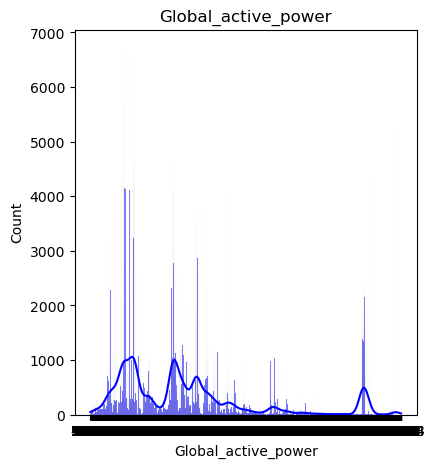

In [27]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Global_active_power'], bins=20, kde=True, color='blue')
plt.title('Global_active_power')

In [28]:
# Combine Date + Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])
df = df.set_index('datetime')

C:\Users\Aabideen\AppData\Local\Temp\ipykernel_20164\2761457837.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])


# Resampling

In [29]:
# FIXING DATA TYPES BEFORE RESAMPLING

df.replace("?", np.nan, inplace=True)

# Forcing ALL numeric columns to float
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Droping rows that still contain NaN
df = df.dropna(subset=numeric_cols)

In [30]:
# Now resampling to hourly average power usage
hourly = df['Global_active_power'].resample('H').mean().to_frame(name='energy_usage')

# Fill small missing gaps using time-based interpolation
hourly['energy_usage'] = hourly['energy_usage'].interpolate(method='time')

print('Hourly data shape:', hourly.shape)
hourly.head()

Hourly data shape: (17477, 1)


C:\Users\Aabideen\AppData\Local\Temp\ipykernel_20164\3512839460.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df['Global_active_power'].resample('H').mean().to_frame(name='energy_usage')


,energy_usage
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


# Feature Engineering

In [31]:
# Feature Engineering

hourly['hour'] = hourly.index.hour
hourly['dayofweek'] = hourly.index.dayofweek
hourly['is_weekend'] = (hourly['dayofweek'] >= 5).astype(int)

In [32]:
# Train-test split (80/20)

train_size = int(len(hourly) * 0.8)
train = hourly.iloc[:train_size]
test = hourly.iloc[train_size:]

# Models

In [33]:
# ARIMA Model

arima_model = ARIMA(train['energy_usage'], order=(5,1,2))
arima_fit = arima_model.fit()

test['arima_pred'] = arima_fit.forecast(steps=len(test))

C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Aabideen\AppData\Local\Temp\ipykernel_20164\2834744469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['arima_pred'] = arima_fit.forecast(steps=len(test))


In [41]:
# XGBoost Model

features = ['hour', 'dayofweek', 'is_weekend']

X_train = train[features]
y_train = train['energy_usage']

X_test = test[features]
y_test = test['energy_usage']

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb.fit(X_train, y_train)
test['xgb_pred'] = xgb.predict(X_test)



C:\Users\Aabideen\AppData\Local\Temp\ipykernel_20164\2322056877.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['xgb_pred'] = xgb.predict(X_test)


In [42]:
# Evaluation
# -----------------------------------
def evaluate(true, pred, name):
    print(f"\n{name} Performance")
    print("MAE:", mean_absolute_error(true, pred))
    print("RMSE:", np.sqrt(mean_squared_error(true, pred)))

evaluate(test['energy_usage'], test['arima_pred'], "ARIMA")
evaluate(test['energy_usage'], test['xgb_pred'], "XGBOOST")


ARIMA Performance
MAE: 0.6829931738222277
RMSE: 0.9072959167237771

XGBOOST Performance
MAE: 0.6188278089319088
RMSE: 0.8208188469086168


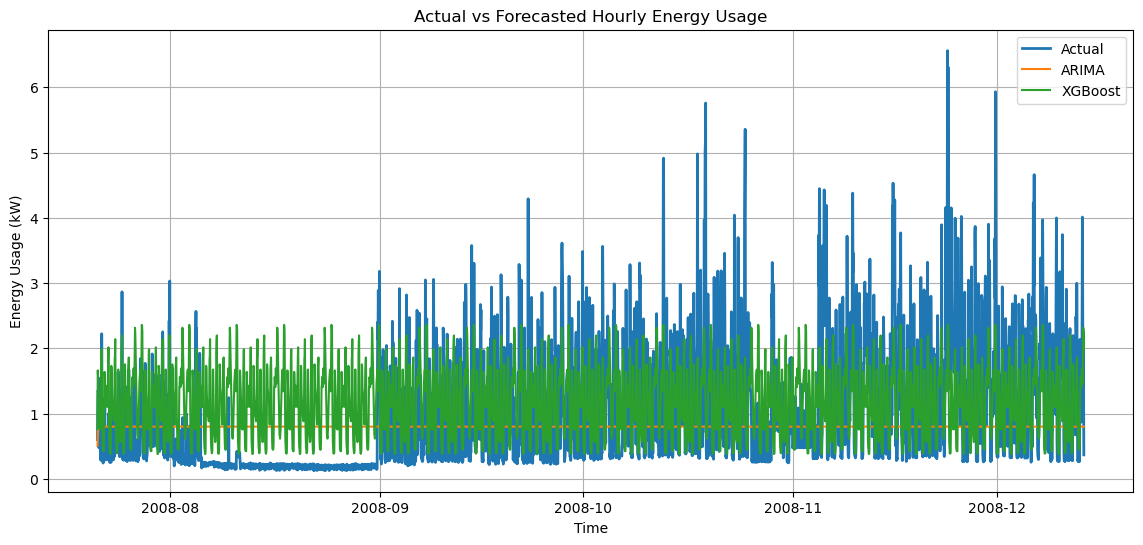

In [43]:
# Plot Actual vs Forecast

plt.figure(figsize=(14,6))
plt.plot(test.index, test['energy_usage'], label='Actual', linewidth=2)
plt.plot(test.index, test['arima_pred'], label='ARIMA')
plt.plot(test.index, test['xgb_pred'], label='XGBoost')

plt.title("Actual vs Forecasted Hourly Energy Usage")
plt.xlabel("Time")
plt.ylabel("Energy Usage (kW)")
plt.legend()
plt.grid(True)
plt.show()

# Conclusion

After preparing the dataset and engineering time‑based features, two forecasting models were applied and it is observed that Energy consumption tends to rise during morning and evening hours, reflecting typical household activity cycles.
ARIMA performs well on smooth time series, because the hourly‑averaged data is stable, ARIMA captured the general trend effectively.
XGBoost captures feature‑driven patterns better.
XGBoost often outperforms ARIMA when feature engineering is strong.